In [1]:
%env CUDA_VISIBLE_DEVICES=0,3
# %env LD_LIBRARY_PATH = ''
try:
  from typing import Literal
  ModelName = Literal["MViTv2-B", "MViTv2-S", "MViTv2-L", "MViTv2-T", ]
except ImportError:
  ModelName = str
import torch
import torchvision.transforms.functional as F
import numpy as np
from mvit.datasets.tractoembedding import Tractoembedding

gpus_str = ''
gpus_list = []
# for i in range(torch.cuda.device_count()):
#     used,all=torch.cuda.mem_get_info(device=i)
#     if used/all >=0.80:
#         gpus_str+=f'{i},'
#         gpus_list += [i]
# os.environ['CUDA_VISIBLE_DEVICES'] = gpus_str[:-1]
# world_size = num_proc * num_shards
# rank = shard_id * num_proc + local_rank
from matplotlib import pyplot as plt
def load_model_and_preproc(model="MViTv2-mri", use_cuda:bool=torch.cuda.is_available(), use_half:bool=True):
    """
    Load an MViT2 model and get the image transformer
    :param model: the name of the model. Should be  one of "MViTv2-B", "MViTv2-S", "MViTv2-L", "MViTv2-T". Defaults to "MViTv2-B".
    :param use_cuda: whether to use cuda. Defaults to True if cuda is available.
    :param use_half: whether to use half-precision. Defaults to True, but will not be used if cuda is not used.
    :returns a tuple of (the model, image transformer)
    """
    model = model.replace('-','_')
    use_half &= use_cuda

    import urllib.request
    from mvit.config.defaults import get_cfg
    from mvit.models import build_model
    from mvit.datasets import Tractoembedding
    from mvit.datasets import loader
    mode = 'fusion'#多模态融合模式，FA1,density，trace1
    ckpt_path = '/data01/zixi/TractoFormer/TractoFormer-MVIT-main/output_PPMI_v1_2/checkpoints/checkpoint_epoch_00115.pyth'
    # ckpt_path = f"/data04/junyi/results/mvit_balanced_fold_new_norm_direct/{mode}_3_030_0123/checkpoints/checkpoint_epoch_00160.pyth"
    # if not os.path.exists(ckpt_path):
    #     urllib.request.urlretrieve(f"https://dl.fbaipublicfiles.com/mvit/mvitv2_models/{ckpt_path}", ckpt_path)
    cfg = get_cfg()
    
    # cfg.MVIT.CLS_EMBED_ON = True
    cfg.DATA.PATH_TO_DATA_DIR = '/data01/zixi/TractoFormer/TractoFormer-MVIT-main/fold_140_balanced_5fold_sorted_age.csv'
    # cfg.merge_from_file(f"./configs/test/{model.replace('ViT','VIT')}_test.yaml")
    cfg.merge_from_file('configs/MVITv2_mri.yaml')
    cfg.DATA.MODE = 'fusion'
    cfg.MVIT.CLS_EMBED_ON = True
    cfg.DATA_AUG_NUM =1
    cfg.DATA_NUM = 3
    cfg.NUM_GPUS = 1
    cfg.DATA_MODE = mode
    cfg.TRAIN.BATCH_SIZE = 4

    model = build_model(cfg)
    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt["model_state"])
    
    model.eval()
    # if use_half:
    #     model = model.half()
    return model,loader.construct_loader(cfg, "val",0)
    
model, datagen = load_model_and_preproc()
datagen.dataset.return_subid = True
input_images, labels, sub_ids = next(iter(datagen))
print("当前 batch 的脑 ID:", sub_ids)

env: CUDA_VISIBLE_DEVICES=0,3


/tmp/ipykernel_2325591/3302724806.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path)


<class 'mvit.datasets.tractoembedding.Tractoembedding'>
(4, 3)
当前 batch 的脑 ID: tensor([3104, 3107, 3111, 3112])


In [2]:
ckpt = torch.load('/data01/zixi/TractoFormer/TractoFormer-MVIT-main/output_PPMI_v1_2/checkpoints/checkpoint_epoch_00115.pyth', map_location='cpu')
print([k for k in ckpt["model_state"].keys() if "blocks" in k][:20])


/tmp/ipykernel_2325591/1982680903.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('/data01/zixi/TractoFormer/TractoFormer-MVIT-main/output_PPMI_v1_2/ch

['model_list.0.blocks.0.norm1.weight', 'model_list.0.blocks.0.norm1.bias', 'model_list.0.blocks.0.attn.rel_pos_h', 'model_list.0.blocks.0.attn.rel_pos_w', 'model_list.0.blocks.0.attn.qkv.weight', 'model_list.0.blocks.0.attn.qkv.bias', 'model_list.0.blocks.0.attn.proj.weight', 'model_list.0.blocks.0.attn.proj.bias', 'model_list.0.blocks.0.attn.pool_q.weight', 'model_list.0.blocks.0.attn.norm_q.weight', 'model_list.0.blocks.0.attn.norm_q.bias', 'model_list.0.blocks.0.attn.pool_k.weight', 'model_list.0.blocks.0.attn.norm_k.weight', 'model_list.0.blocks.0.attn.norm_k.bias', 'model_list.0.blocks.0.attn.pool_v.weight', 'model_list.0.blocks.0.attn.norm_v.weight', 'model_list.0.blocks.0.attn.norm_v.bias', 'model_list.0.blocks.0.norm2.weight', 'model_list.0.blocks.0.norm2.bias', 'model_list.0.blocks.0.mlp.fc1.weight']


In [ ]:
# input_images, labels, sub_ids = next(iter(datagen))
# print("当前 batch 的脑 ID:", sub_ids)
# # input_images, labels= next(iter(datagen))


In [ ]:
# for input_images,labels in datagen:
#     img = input_images[0][0][0]
#     mask = img!=0
#     # mt = masked_tensor(img,img!=0)
#     mean = img.mean((2,3),  keepdim=True).mean(0,keepdim=True)
#     std = img.std((2,3),keepdim=True).mean(0,keepdim=True)
#     img1 = ((img-mean)/std)
#     # img1[~mask] = 0
#     print(mean.squeeze(),std.squeeze())
    

In [3]:
allimages = []
for images4model in input_images[0]:
    imagecuda = [image.cuda() for image in images4model]
    allimages.append(imagecuda)
print(f"PyTorch sees {torch.cuda.device_count()} GPU(s).")
print(f"Using device: {torch.cuda.current_device()} → {torch.cuda.get_device_name(torch.cuda.current_device())}")


PyTorch sees 2 GPU(s).
Using device: 0 → NVIDIA GeForce RTX 3090


In [4]:
with torch.no_grad():   
    model.eval()
    preds = model(allimages)
mixed = [((labels==0)&(preds==labels)).float().sum(),
                 ((labels==0)&(preds!=labels)).float().sum(),
                 ((labels==1)&(preds==labels)).float().sum(),
                 ((labels==1)&(preds!=labels)).float().sum()]
prec = mixed[0]/(mixed[0]+mixed[1])
recall = mixed[0]/(mixed[0]+mixed[3])
f1 = 2*prec*recall/(prec+recall)


=========== FusionModel forward ===========
len(xs) = 3

--- branch 0 input ---
type(x) = <class 'list'>
len(x) = 3
  x[0] shape=(4, 3, 320, 320) dtype=torch.float32 device=cuda:0 min=0.0000 max=16.0000
  x[1] shape=(4, 3, 160, 160) dtype=torch.float32 device=cuda:0 min=0.0000 max=42.0000
  x[2] shape=(4, 3, 80, 80) dtype=torch.float32 device=cuda:0 min=0.0000 max=127.0000
--- branch 0 pred ---
pred shape = (4, 2) min= 0.3753913938999176 max= 0.6246086359024048
blocks[0].attn.attn_lst shape = (4, 1, 6401, 401)

--- branch 1 input ---
type(x) = <class 'list'>
len(x) = 3
  x[0] shape=(4, 3, 320, 320) dtype=torch.float32 device=cuda:0 min=0.0000 max=16.0000
  x[1] shape=(4, 3, 160, 160) dtype=torch.float32 device=cuda:0 min=0.0000 max=42.0000
  x[2] shape=(4, 3, 80, 80) dtype=torch.float32 device=cuda:0 min=0.0000 max=127.0000
--- branch 1 pred ---
pred shape = (4, 2) min= 0.3949461281299591 max= 0.6050538420677185
blocks[0].attn.attn_lst shape = (4, 1, 6401, 401)

--- branch 2 input ---

RuntimeError: The size of tensor a (2) must match the size of tensor b (4) at non-singleton dimension 1

tensor([True, True, True, True], device='cuda:0')
58
(142833, 2) (142833, 4, 4)
[]
pi 0 block 0 attn shape torch.Size([4, 1, 6401, 401])
(142833, 2) (142833, 4, 4)
[]
pi 1 block 2 attn shape torch.Size([4, 2, 1601, 401])
(142833, 2) (142833, 4, 4)
[b'T_CC4_comm' b'T_CC5_comm' b'T_CC6_comm' b'T_CC7_comm' b'T_CPC_left'
 b'T_CPC_right' b'T_CR-F_left' b'T_CR-F_right' b'T_CR-P_right'
 b'T_CST_left' b'T_CST_right' b'T_EC_left' b'T_EC_right' b'T_EmC_left'
 b'T_EmC_right' b'T_ILF_left']
pi 1 block 2 attn shape torch.Size([4, 2, 1601, 401])
(142833, 2) (142833, 4, 4)
[]
pi 2 block 4 attn shape torch.Size([4, 4, 401, 401])
(142833, 2) (142833, 4, 4)
[]
pi 2 block 4 attn shape torch.Size([4, 4, 401, 401])
(142833, 2) (142833, 4, 4)
[]
pi 2 block 4 attn shape torch.Size([4, 4, 401, 401])
(142833, 2) (142833, 4, 4)
[]
pi 2 block 4 attn shape torch.Size([4, 4, 401, 401])
(142833, 2) (142833, 4, 4)
[b'T_MdLF_left' b'T_MdLF_right' b'T_PLIC_right' b'T_SF_left' b'T_SF_right'
 b'T_SLF-III_right' b'T_SLF-

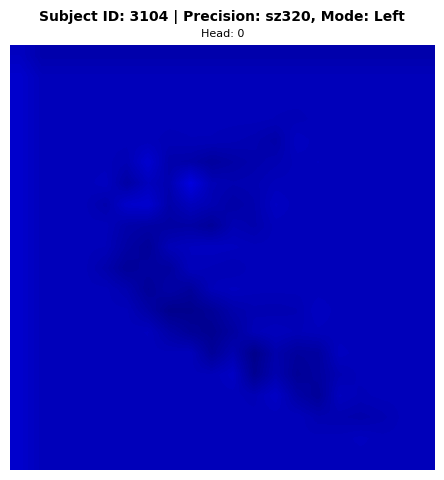

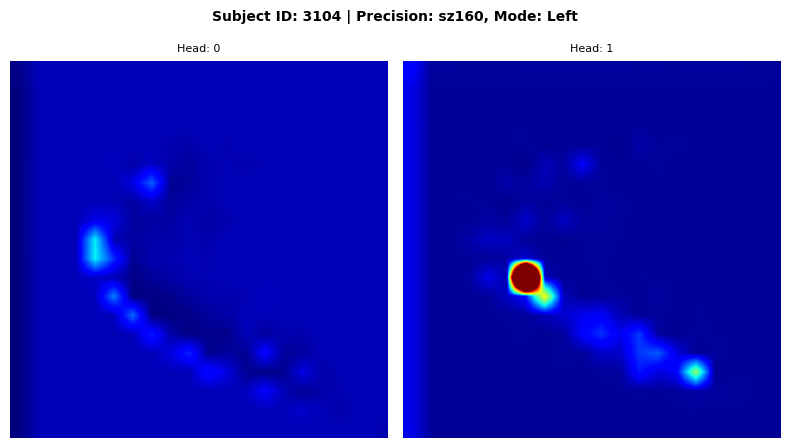

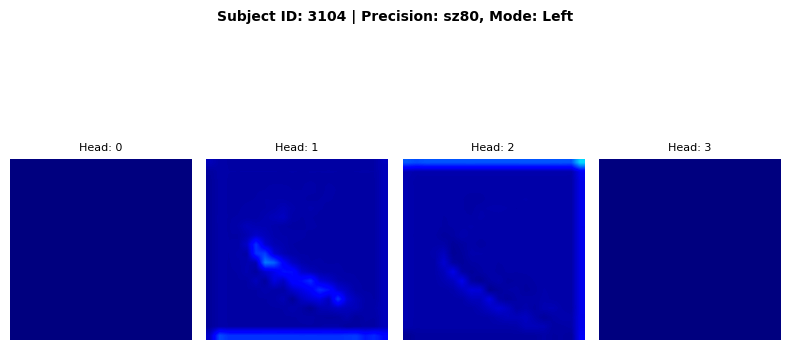

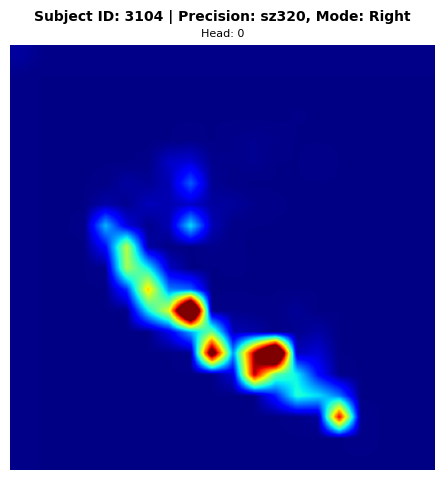

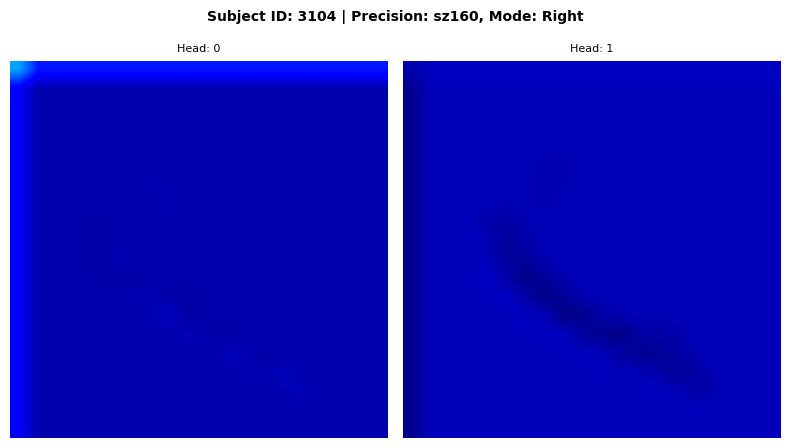

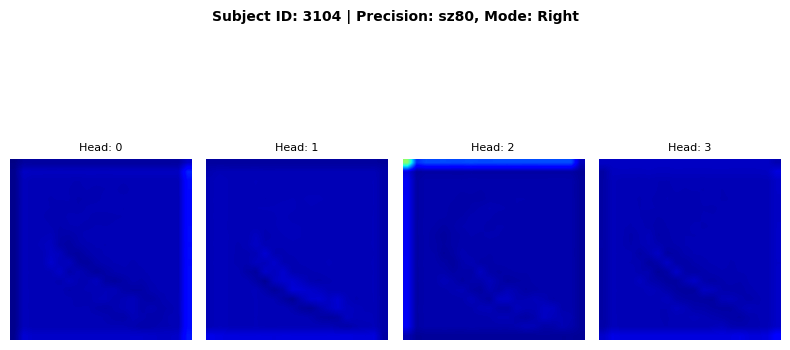

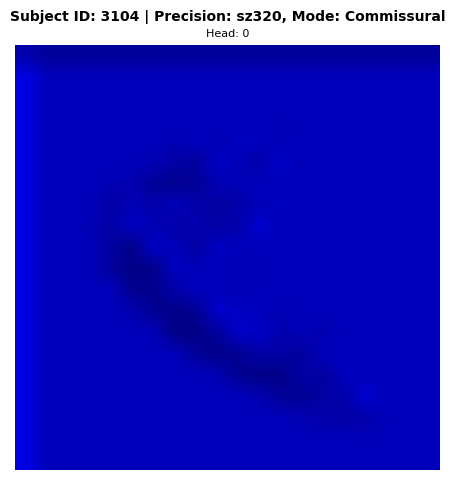

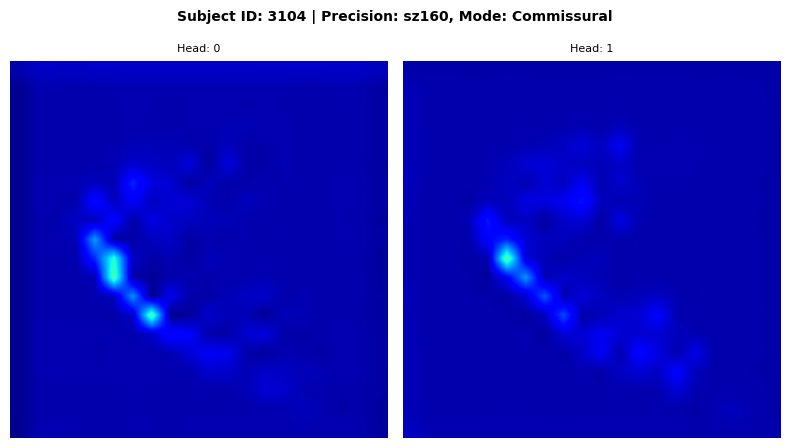

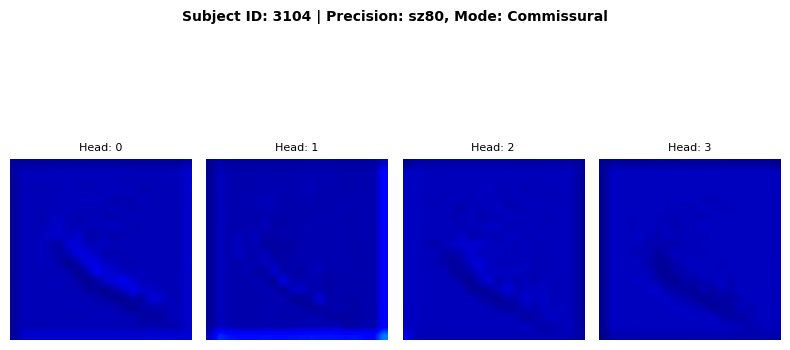

In [5]:
#原初版本的attention提取代码
from itertools import product
import pathlib
import torch
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import os
precison_list = ['sz80', 'sz160', 'sz320',]
precison_list.reverse()
mode_list = ['Left', 'Right', 'Commissural']

v, i = torch.topk(preds, 1)
labels = labels.cuda()
m = labels == i.squeeze()
print(m)


import h5py

f = h5py.File('/data01/zixi/tractoembedding_PPMI_143/3104/tracts/3104.h5', "r")
tract_list = f['tract_list'][:]
tract_name = f['tract_name'][:]
print(len(np.unique(tract_name)))

# ✅ 只加这一行，假设你有 sub_ids 变量
sub_id = sub_ids[0].item() if torch.is_tensor(sub_ids[0]) else sub_ids[0]
os.makedirs("./attns", exist_ok=True)
for mi, pi in product(range(3), range(3)):
    attns = model.model_list[mi].blocks[2*pi].attn.attn_lst[m, :, 0, 1:].mean(0, keepdim=True)
    B, nH, nP = attns.shape
    fig = plt.figure(figsize=(8, 5))
    for head in range(nH):
        attn = attns[0, head].reshape(-1, 20, 20).cpu()
        mask = F.resize(attn, input_images[0][0][0].shape[-2:], F.InterpolationMode.BILINEAR)
        # 保存为 .npy 文件
        npy_path = f'./attns/{sub_id}_precision_{precison_list[pi]}_mode_{mode_list[mi]}_head{head}.npy'
        np.save(npy_path, mask.numpy())
        
        embed_feat = np.load('/data01/zixi/tractoembedding_PPMI_143/3104/embed_feat.npy')
        embed = np.load('/data01/zixi/tractoembedding_PPMI_143/3104/embed.npy')
        
        print(embed.shape, embed_feat.shape)

        true_x, true_y = np.where(mask[0] > 0.05)
        indice = true_x + true_y * mask.shape[-1]
        
        fiber_indices = np.load('/data01/zixi/tractoembedding_PPMI_143/3104/tractoembedding/da-full/fiber_indices.npy')
        true_fiber_indices = fiber_indices[indice]
        
        print(np.unique(tract_name[tract_list[true_fiber_indices].astype(int)]))
        
        print("pi", pi, "block", 2*pi, "attn shape", model.model_list[mi].blocks[2*pi].attn.attn_lst.shape)


        ax = plt.subplot(1, nH, head + 1, frameon=False)
        ax.imshow(mask[0], vmin=0, vmax=0.05, cmap='jet')
        ax.axis('off')
        ax.set_title(f'Head: {head}', fontsize=8)
    
    # ✅ 在这里标题中加上 ID
    fig.suptitle(
        f'Subject ID: {sub_id} | Precision: {precison_list[pi]}, Mode: {mode_list[mi]}',
        fontsize=10, fontweight='bold', y=0.95
    )
    
    fig.tight_layout()
    pathlib.Path('./attns').mkdir(exist_ok=True)
    fig.savefig(f'./attns/precision_{precison_list[pi]}_mode_{mode_list[mi]}.png', dpi=300)

In [ ]:
# 用 attention 选 streamline → 用几何阈值(0.6)做 Left/Right/Commissural 划分 → 再统计 tract 排名（写txt）
# ✅ 不再用 tract_name 的 left/right/comm 来做 in_mode（避免“名单外 commissural”混入 left/right）
# ✅ 中线可调：MIDLINE_X 手动 or 自动估计；支持中线灰区 MIDLINE_DELTA
# ✅ 可选每条 streamline 重采样到固定点数（默认 40，更接近 wma）
# ✅ 修复 attention 映射：改用 fiber_indices.npy 做 pixel→fiber 命中（与最初提取一致），避免 embed 映射不一致
#
# ✅ 本版本改动点（按你的要求）：
#   只把“attention → core”提取方式改成和 overlay 脚本一致：
#   - percentile 阈值
#   - opening -> closing
#   - 连通域按 attention 得分选择（mean/max/mean_x_area）
#   - 支持 transpose 对齐（与 overlay 的 transpose=True 对齐）
#   其他所有 streamline 几何划分/过滤/保存逻辑保持不变。

import os
import re
import numpy as np
import pyvista as pv
from scipy import ndimage as ndi
import torch
import torch.nn.functional as tF
import h5py
from collections import Counter

# =========================
# 用户参数区（重点看这里）
# =========================
sub_id = "sub-50016"
precision = "sz320"
modes = ["Left", "Right", "Commissural"]
heads = [0]

attn_dir = "/data01/zixi/TractoFormer/TractoFormer-MVIT-main/attns"
embed_path = f"/data01/zixi/tractoembedding_PPMI_143/{sub_id}/embed.npy"
vtp_path   = f"/data01/zixi/tractoembedding_PPMI_143/{sub_id}/tracts/{sub_id}.vtp"
h5_path    = f"/data01/zixi/tractoembedding_PPMI_143/{sub_id}/tracts/{sub_id}.h5"

out_dir = "./circled_streamlines_vtp"
os.makedirs(out_dir, exist_ok=True)

tract_txt_dir = os.path.join(out_dir, "tract_stats_txt")
os.makedirs(tract_txt_dir, exist_ok=True)

# --- 几何 hemisphere 划分参数 ---
HEMI_PTHRESH = 0.6
MIDLINE_X = None
MIDLINE_DELTA = 1.0

# --- 是否在 Left/Right 再额外剔除 tract_name 命中的 comm（兜底保险）---
DROP_NAME_COMM_IN_LR = True

# --- 是否重采样每条 streamline 到固定点数（更接近 wma） ---
RESAMPLE_POINTS_PER_FIBER = 40

# --- attention core percentile（保持你原来的，不改）
MODE_PERCENTILE = {
    "Left": 95,
    "Right": 98,
    "Commissural": 62,
}

# --- 与 overlay 对齐的 core 提取细节 ---
COMPONENT_SCORE = "mean"   # "mean" | "max" | "mean_x_area"  —— 与 overlay 一致
ATTN_TRANSPOSE = False      # 与 overlay 的 transpose_flag=True 对齐（如仍不对齐，改 False 测试）

TOPK_COMPONENTS = 1
MIN_AREA = 10
MIN_RATIO = 0.00
EPS = 1e-12

HEAD_FUSION = "union"
VOTE_K = 2

# =========================
# 通用映射
# =========================
MODE_LABEL = {"Left": 1, "Right": 2, "Commissural": 3}

D = int(precision.replace("sz", ""))
scale_map = {80: 12.5, 160: 25, 320: 50, 640: 100, 1280: 200}
assert D in scale_map, f"Unsupported D={D}, extend scale_map if needed."
scale = scale_map[D]
offset = D / 2 - D / 10


def resize_attn_to(attn2d: np.ndarray, target_hw):
    a = np.squeeze(attn2d)
    if a.ndim != 2:
        raise ValueError(f"resize_attn_to expects 2D, got {attn2d.shape} -> {a.shape}")
    x = torch.from_numpy(a).float()[None, None, ...]
    x = tF.interpolate(x, size=target_hw, mode="bilinear", align_corners=False)
    return x[0, 0].cpu().numpy()


def largest_components_mask(binary_mask: np.ndarray, topk: int, min_area: int, min_ratio: float):
    lab, ncc = ndi.label(binary_mask)
    if ncc == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    total = int(binary_mask.sum())
    comps = []
    for i in range(1, ncc + 1):
        m = (lab == i)
        area = int(m.sum())
        if area < min_area:
            continue
        if total > 0 and (area / total) < min_ratio:
            continue
        comps.append((area, m))

    if not comps:
        return np.zeros_like(binary_mask, dtype=bool)

    comps.sort(key=lambda x: -x[0])
    out = np.zeros_like(binary_mask, dtype=bool)
    for _, m in comps[:topk]:
        out |= m
    return out


# =========================
# ✅ 改成 overlay 同款：连通域按 attention 得分选
# =========================
def select_components_by_attn(binary_mask: np.ndarray,
                              attn2d: np.ndarray,
                              topk: int = 1,
                              min_area: int = 30,
                              min_ratio: float = 0.0,
                              score_mode: str = "mean") -> np.ndarray:
    lab, ncc = ndi.label(binary_mask)
    if ncc == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    total = int(binary_mask.sum())
    comps = []
    for cc in range(1, ncc + 1):
        m = (lab == cc)
        area = int(m.sum())
        if area < min_area:
            continue
        if total > 0 and (area / total) < min_ratio:
            continue

        vals = attn2d[m]
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue

        if score_mode == "mean":
            score = float(vals.mean())
        elif score_mode == "max":
            score = float(vals.max())
        elif score_mode == "mean_x_area":
            score = float(vals.mean() * area)
        else:
            raise ValueError("score_mode must be 'mean', 'max', or 'mean_x_area'")

        comps.append((score, area, m))

    if not comps:
        return np.zeros_like(binary_mask, dtype=bool)

    comps.sort(key=lambda x: (-x[0], -x[1]))
    out = np.zeros_like(binary_mask, dtype=bool)
    for _, _, m in comps[:topk]:
        out |= m
    return out


def core_from_percentile_attn(attn2d: np.ndarray, percentile: float):
    """
    与 overlay 的 core_from_percentile 同款：
    - valid = attn>0 且 finite
    - 阈值 = percentile(valid)
    - opening -> closing
    - 连通域按 attention 得分选
    """
    valid = attn2d[(attn2d > 0) & np.isfinite(attn2d)]
    if valid.size > 0:
        T = np.percentile(valid, percentile)
    else:
        T = np.percentile(attn2d[np.isfinite(attn2d)], percentile)

    core = (attn2d >= (T - EPS))
    core = ndi.binary_opening(core, iterations=1)
    core = ndi.binary_closing(core, iterations=1)
    core = select_components_by_attn(
        core, attn2d,
        topk=TOPK_COMPONENTS,
        min_area=MIN_AREA,
        min_ratio=MIN_RATIO,
        score_mode=COMPONENT_SCORE
    )
    return core.astype(bool), float(T)


# =========================
# tract_name / comm 兜底（可选）
# =========================
def is_commissural_name_strict(name: str) -> bool:
    low = name.lower()
    if "comm" in low:
        return True
    if re.search(r"(^|_)cc\d+(_|$)", low):
        return True
    if re.search(r"(^|_)cc(_|$)", low):
        return True
    return False


# =========================
# 几何划分：可选重采样到固定点数
# =========================
def resample_polyline(points_xyz: np.ndarray, m: int = 40) -> np.ndarray:
    if points_xyz.shape[0] <= 2 or m is None:
        return points_xyz
    seg = np.linalg.norm(points_xyz[1:] - points_xyz[:-1], axis=1)
    s = np.concatenate([[0.0], np.cumsum(seg)])
    total = s[-1]
    if total <= 0:
        return points_xyz[:1].repeat(m, axis=0)
    t = np.linspace(0.0, total, m)
    out = np.zeros((m, 3), dtype=points_xyz.dtype)
    for k in range(3):
        out[:, k] = np.interp(t, s, points_xyz[:, k])
    return out


def geo_mode_from_points(points_xyz: np.ndarray,
                         mid_x: float,
                         pthresh: float = 0.6,
                         delta: float = 0.0) -> int:
    x = points_xyz[:, 0] - mid_x
    left_mask = (x < -delta)
    right_mask = (x > +delta)
    nL = int(left_mask.sum())
    nR = int(right_mask.sum())
    denom = nL + nR
    if denom == 0:
        return MODE_LABEL["Commissural"]
    rL = nL / denom
    rR = nR / denom
    if rL >= pthresh:
        return MODE_LABEL["Left"]
    if rR >= pthresh:
        return MODE_LABEL["Right"]
    return MODE_LABEL["Commissural"]


def estimate_midline_x(mesh: pv.PolyData) -> float:
    xs = mesh.points[:, 0]
    return float(np.median(xs))


# =========================
# 读取 tract_list / tract_name
# =========================
assert os.path.exists(h5_path), f"Missing h5: {h5_path}"
with h5py.File(h5_path, "r") as f:
    tract_list = f["tract_list"][:]
    tract_name = f["tract_name"][:]

tract_name = np.array([
    x.decode("utf-8") if isinstance(x, (bytes, np.bytes_)) else str(x)
    for x in tract_name
])

tract_ids_all = tract_list.astype(np.int64)
tract_ids_all = np.clip(tract_ids_all, 0, len(tract_name) - 1)

tract_is_comm = np.array([is_commissural_name_strict(n) for n in tract_name], dtype=bool)
fiber_is_comm = tract_is_comm[tract_ids_all]  # (N,)

# =========================
# load embed + mesh
# =========================
embed = np.load(embed_path)  # (N,2) —— 仍然加载，但后面不再用于 attention 命中
mesh = pv.read(vtp_path)
assert mesh.n_cells == embed.shape[0], f"mesh.n_cells {mesh.n_cells} != embed N {embed.shape[0]}"
N = mesh.n_cells
assert tract_ids_all.shape[0] == N, f"tract_list len {tract_ids_all.shape[0]} != N {N}"

# （保留 dx/dy 的计算，但后面不再用于 in_circle）
dx = np.clip(np.round(embed[:, 0] * scale + offset).astype(int), 0, D - 1)
dy = np.clip(np.round(embed[:, 1] * scale + offset).astype(int), 0, D - 1)

print(f"[debug] commissural fibers (by name): {int(fiber_is_comm.sum())} / {N}")

fiber_indices_path = f"/data01/zixi/tractoembedding_PPMI_143/{sub_id}/tractoembedding/da-full/fiber_indices.npy"
use_pixel2fiber = False
fiber_indices = None

if os.path.exists(fiber_indices_path):
    fiber_indices = np.load(fiber_indices_path)
    fiber_indices = np.asarray(fiber_indices)
    if fiber_indices.ndim == 1 and fiber_indices.size == D * D:
        use_pixel2fiber = True
        fiber_indices = fiber_indices.astype(np.int64)
        fiber_indices = np.clip(fiber_indices, 0, N - 1)
        print(f"[attn-map] use pixel2fiber mapping from fiber_indices.npy (size={fiber_indices.size})")
    else:
        print(f"[attn-map] fiber_indices.npy exists but shape={fiber_indices.shape} (size={fiber_indices.size}), "
              f"not D*D={D*D}. Will fall back to embed(dx,dy) mapping.")
else:
    print("[attn-map] fiber_indices.npy not found, fall back to embed(dx,dy) mapping.")


def coremask_to_hit_fibers(core_mask_bool: np.ndarray) -> np.ndarray:
    core_mask_bool = core_mask_bool.astype(bool)
    if use_pixel2fiber:
        rows, cols = np.where(core_mask_bool)  # rows=y, cols=x
        if rows.size == 0:
            return np.zeros((N,), dtype=bool)
        lin = rows * D + cols
        hit_ids = np.unique(fiber_indices[lin])
        hit = np.zeros((N,), dtype=bool)
        hit[hit_ids] = True
        return hit
    else:
        # fallback: embed-based (your original correct-by-definition way)
        return core_mask_bool[dy, dx]


# =========================
# ✅ 关键改动：几何 hemisphere 划分（原样保留，不改）
# =========================
mid_x = estimate_midline_x(mesh) if MIDLINE_X is None else float(MIDLINE_X)
print(f"[geo] midline_x = {mid_x:.4f}  (MIDLINE_X={'auto(median)' if MIDLINE_X is None else 'manual'})")
print(f"[geo] HEMI_PTHRESH={HEMI_PTHRESH}, MIDLINE_DELTA={MIDLINE_DELTA}, RESAMPLE_POINTS_PER_FIBER={RESAMPLE_POINTS_PER_FIBER}")

geo_mode = np.zeros(N, dtype=np.int8)

pts_all = mesh.points
lines = mesh.lines
idx = 0
for fi in range(N):
    npts = int(lines[idx])
    ids = lines[idx + 1: idx + 1 + npts]
    idx += 1 + npts

    pts = pts_all[ids]
    if RESAMPLE_POINTS_PER_FIBER is not None:
        pts = resample_polyline(pts, RESAMPLE_POINTS_PER_FIBER)

    geo_mode[fi] = geo_mode_from_points(
        pts, mid_x=mid_x, pthresh=HEMI_PTHRESH, delta=MIDLINE_DELTA
    )

    if (fi + 1) % 50000 == 0:
        print(f"[geo] processed {fi+1}/{N} fibers...")

print(f"[geo] Left={int(np.sum(geo_mode==1))}, Right={int(np.sum(geo_mode==2))}, Comm={int(np.sum(geo_mode==3))} / N={N}")


# =========================
# 统计 + 保存
# =========================
def save_tract_stats(mode: str, ids: np.ndarray):
    if ids.size == 0:
        txt_path = os.path.join(tract_txt_dir, f"{sub_id}_{precision}_{mode}_tracts.txt")
        with open(txt_path, "w", encoding="utf-8") as w:
            w.write("EMPTY (no streamlines selected)\n")
        print(f"    [tract] saved empty:", txt_path)
        return

    tract_ids = tract_ids_all[ids]
    names = tract_name[tract_ids].tolist()

    cnt = Counter(names)
    total = sum(cnt.values())
    items = sorted(cnt.items(), key=lambda x: (-x[1], x[0]))

    print(f"    [tract] mode={mode} unique_tracts={len(items)} total_streamlines(matched)={total}")
    for name, c in items[:10]:
        print(f"        {name:>20s} : {c} ({c/total:.3%})")

    txt_path = os.path.join(tract_txt_dir, f"{sub_id}_{precision}_{mode}_tracts.txt")
    with open(txt_path, "w", encoding="utf-8") as w:
        w.write(f"sub_id={sub_id}\nprecision={precision}\nmode={mode}\n")
        w.write(f"selected_streamlines={int(ids.size)}\n")
        w.write(f"matched_streamlines_for_stats={int(total)}\n")
        w.write("--------------------------------------------------\n")
        w.write("rank\tcount\tratio\ttract_name\n")
        for r, (name, c) in enumerate(items, 1):
            w.write(f"{r}\t{c}\t{c/total:.6f}\t{name}\n")
    print(f"    [tract] saved:", txt_path)


# =========================
# main per mode
# =========================
for mode in modes:
    p = float(MODE_PERCENTILE[mode])
    core_list = []
    attn_list = []

    for head in heads:
        attn_path = f"{attn_dir}/{sub_id}_precision_{precision}_mode_{mode}_head{head}.npy"
        if not os.path.exists(attn_path):
            print("[skip missing]", attn_path)
            continue

        attn = np.squeeze(np.load(attn_path))
        if attn.ndim != 2:
            raise ValueError(f"attn must be 2D after squeeze, got {attn.shape} from {attn_path}")
        if attn.shape != (D, D):
            attn = resize_attn_to(attn, (D, D))

        # ✅ 与 overlay 对齐：transpose=True（可通过 ATTN_TRANSPOSE 开关控制）
        if ATTN_TRANSPOSE:
            attn = attn.T

        # 把 NaN/Inf 清掉
        attn = attn.copy()
        attn[~np.isfinite(attn)] = 0.0

        # ✅ 与 overlay 对齐：core 提取
        core, T = core_from_percentile_attn(attn, p)
        core_list.append(core)
        attn_list.append(attn)

        print(f"[{mode}] head{head} P{p} T={T:.6f} core_pixels={int(core.sum())}")

    if not core_list:
        print(f"[warn] no attention found for mode={mode}")
        continue

    core_stack = np.stack(core_list, axis=0)
    if HEAD_FUSION == "union":
        core_final = np.any(core_stack, axis=0)
    elif HEAD_FUSION == "vote":
        core_final = (np.sum(core_stack, axis=0) >= VOTE_K)
    else:
        raise ValueError("HEAD_FUSION must be 'union' or 'vote'")

    # ✅ 与 overlay 对齐：融合后再做一次轻度清理 + 按 attn_avg 得分选连通域
    attn_avg = np.mean(np.stack(attn_list, axis=0), axis=0)
    core_final = ndi.binary_opening(core_final, iterations=1)
    core_final = ndi.binary_closing(core_final, iterations=1)
    core_final = select_components_by_attn(
        core_final, attn_avg,
        topk=TOPK_COMPONENTS,
        min_area=MIN_AREA,
        min_ratio=MIN_RATIO,
        score_mode=COMPONENT_SCORE
    ).astype(bool)

    # =========================
    # ✅ 后面的 hit_fibers / geo_mode / 保存逻辑保持不变
    # =========================
    hit_fibers = coremask_to_hit_fibers(core_final)
    print("  in_circle:", int(hit_fibers.sum()), "/", N)
    print("  in_circle(hit_fibers):", int(hit_fibers.sum()), "/", N)

    want_mode = MODE_LABEL[mode]
    in_mode = (geo_mode == want_mode)

    if mode in ["Left", "Right"] and DROP_NAME_COMM_IN_LR:
        ids = np.where(hit_fibers & in_mode & (~fiber_is_comm))[0]
    else:
        ids = np.where(hit_fibers & in_mode)[0]

    print("  in_geo_mode:", int(in_mode.sum()), "/", N)
    if mode in ["Left", "Right"] and DROP_NAME_COMM_IN_LR:
        print("  non_name_comm:", int((~fiber_is_comm).sum()), "/", N)
        print("  both:", int((hit_fibers & in_mode & (~fiber_is_comm)).sum()), "/", N)
        comm_in_ids = int(fiber_is_comm[ids].sum()) if ids.size else 0
        print(f"  name-comm in ids: {comm_in_ids} / {int(ids.size)}")
    else:
        print("  both:", int((hit_fibers & in_mode).sum()), "/", N)

    print(f"[{mode}] final selected streamlines: {ids.size}")

    save_tract_stats(mode, ids)

    if ids.size == 0:
        continue

    sub = mesh.extract_cells(ids)
    out_vtk = f"{out_dir}/{sub_id}_{precision}_{mode}_circledHeads_{HEAD_FUSION}.vtk"
    sub.save(out_vtk)
    print("    saved:", out_vtk)

print("Done.")
print("Tract stats txt in:", tract_txt_dir)


In [ ]:
import pyvista as pv, h5py, numpy as np
vtp = pv.read("/data01/zixi/tractoembedding_PPMI_143/sub-50016/tracts/sub-50016.vtp")
with h5py.File("/data01/zixi/tractoembedding_PPMI_143/sub-50016/tracts/sub-50016.h5","r") as f:
    tl = f["tract_list"][:]
    tn = f["tract_name"][:]
print("n_cells (fibers) =", vtp.n_cells)
print("tract_list len   =", tl.shape[0])
print("num tracts       =", len(tn))
print("tract_list unique=", len(np.unique(tl)))


In [ ]:
#attention 叠加到fa的nii图上
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as tF
from scipy import ndimage as ndi

sub_id = "3104"
nii_path = "/data01/zixi/tractoembedding_PPMI_143/3104/tractoembedding/da-full/3104-FA1_CLR_sz320.nii.gz"
attn_dir = "/data01/zixi/TractoFormer/TractoFormer-MVIT-main/attns"

modes = ["Left", "Right", "Commissural"]
heads = [0]
precision = "sz320"

out_dir = "./overlays_coreOnly"
os.makedirs(out_dir, exist_ok=True)

MODE_CORE_PERCENTILE = {
    "Left": 97.5,
    "Right": 97.5,
    "Commissural": 93,
}

SHOW_CORE_HEATMAP = True
ATTN_ALPHA = 0.70

TOPK_COMPONENTS = 1
MIN_AREA = 50
MIN_RATIO = 0.00

HEAD_FUSION = "union"
VOTE_K = 2

EMBED_CMAP = "gray"
ATTN_CMAP = "jet"
BRAIN_GAMMA = 0.55
EPS = 1e-12

COMPONENT_SCORE = "mean"   # "mean" | "max" | "mean_x_area"

MODE_CONTOUR_STYLE = {
    "Left":        dict(color="blue",  linestyle="--", linewidth=0.3),
    "Right":       dict(color="green", linestyle="--", linewidth=0.3),
    "Commissural": dict(color="red",   linestyle="--", linewidth=0.3),
}

# --------------------------
# utils
# --------------------------
def normalize_brain_on_black(x: np.ndarray, eps: float = 1e-8, gamma: float = 0.55) -> np.ndarray:
    x = x.astype(np.float32)
    mask = x > 0
    out = np.zeros_like(x, dtype=np.float32)
    if mask.sum() == 0:
        return out
    vals = x[mask]
    lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
    if hi - lo < eps:
        lo, hi = vals.min(), vals.max() + eps
    out[mask] = np.clip((x[mask] - lo) / (hi - lo + eps), 0, 1)
    out[mask] = np.power(out[mask], gamma)
    return out

def resize_to(attn2d: np.ndarray, target_hw) -> np.ndarray:
    Ht, Wt = target_hw
    a = attn2d
    if a.ndim == 3:
        a = np.squeeze(a)
    if a.ndim != 2:
        raise ValueError(f"resize_to expects 2D, got {attn2d.shape} -> {a.shape}")
    x = torch.from_numpy(a).float()[None, None, ...]
    x = tF.interpolate(x, size=(Ht, Wt), mode="bilinear", align_corners=False)
    return x[0, 0].cpu().numpy()

def load_nii_as_3channels(path: str):
    img = nib.load(path)
    data = img.get_fdata()
    print("[nii] raw shape:", data.shape, "dtype:", data.dtype)
    if data.ndim == 3 and data.shape[-1] == 3:
        return data
    if data.ndim == 3 and data.shape[0] == 3:
        return np.transpose(data, (1, 2, 0))
    if data.ndim == 4 and data.shape[-1] == 3:
        z = data.shape[2] // 2
        print("[nii] using middle slice z =", z)
        return data[:, :, z, :]
    if data.ndim == 4 and data.shape[0] == 3:
        z = data.shape[-1] // 2
        print("[nii] using middle slice z =", z)
        base = data[:, :, :, z]
        return np.transpose(base, (1, 2, 0))
    raise ValueError(f"Unsupported nii shape: {data.shape}")

def select_components_by_attn(binary_mask: np.ndarray,
                              attn2d: np.ndarray,
                              topk: int = 1,
                              min_area: int = 30,
                              min_ratio: float = 0.0,
                              score_mode: str = "mean") -> np.ndarray:
    lab, ncc = ndi.label(binary_mask)
    if ncc == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    total = int(binary_mask.sum())
    comps = []
    for cc in range(1, ncc + 1):
        m = (lab == cc)
        area = int(m.sum())
        if area < min_area:
            continue
        if total > 0 and (area / total) < min_ratio:
            continue
        vals = attn2d[m]
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        if score_mode == "mean":
            score = float(vals.mean())
        elif score_mode == "max":
            score = float(vals.max())
        elif score_mode == "mean_x_area":
            score = float(vals.mean() * area)
        else:
            raise ValueError("score_mode must be 'mean', 'max', or 'mean_x_area'")
        comps.append((score, area, m))

    if not comps:
        return np.zeros_like(binary_mask, dtype=bool)

    comps.sort(key=lambda x: (-x[0], -x[1]))
    out = np.zeros_like(binary_mask, dtype=bool)
    for _, _, m in comps[:topk]:
        out |= m
    return out

def core_from_percentile(attn2d: np.ndarray, brain_mask: np.ndarray, percentile: float):
    valid = attn2d[(attn2d > 0) & brain_mask & np.isfinite(attn2d)]
    if valid.size > 0:
        T = np.percentile(valid, percentile)
    else:
        T = np.percentile(attn2d[np.isfinite(attn2d)], percentile)

    core = (attn2d >= (T - EPS)) & brain_mask
    core = ndi.binary_opening(core, iterations=1)
    core = ndi.binary_closing(core, iterations=1)
    core = select_components_by_attn(
        core, attn2d,
        topk=TOPK_COMPONENTS,
        min_area=MIN_AREA,
        min_ratio=MIN_RATIO,
        score_mode=COMPONENT_SCORE
    )
    core = core & brain_mask
    return core, float(T)

def contour_ready_mask(m: np.ndarray, close_iter: int = 3, dilate_iter: int = 1, keep_largest: bool = True) -> np.ndarray:
    m = m.astype(bool)
    if close_iter > 0:
        m = ndi.binary_closing(m, iterations=close_iter)
    m = ndi.binary_fill_holes(m)
    if dilate_iter > 0:
        m = ndi.binary_dilation(m, iterations=dilate_iter)
    if keep_largest:
        lab, ncc = ndi.label(m)
        if ncc > 1:
            sizes = ndi.sum(m, lab, index=np.arange(1, ncc + 1))
            keep = 1 + int(np.argmax(sizes))
            m = (lab == keep)
    return m.astype(bool)

def overlay_core_only(base2d, attn_avg, core_final, out_path, title, p_core, contour_color, contour_linestyle):
    base_n = normalize_brain_on_black(base2d, gamma=BRAIN_GAMMA)
    fig = plt.figure(figsize=(5, 5), facecolor="black")
    ax = fig.add_subplot(111)
    ax.set_facecolor("black")
    ax.imshow(base_n, cmap=EMBED_CMAP, vmin=0, vmax=1)

    if SHOW_CORE_HEATMAP:
        attn_show = attn_avg.copy().astype(np.float32)
        attn_show[~core_final] = np.nan
        vmax = np.nanpercentile(attn_avg, 99.9)
        vmin = np.nanpercentile(attn_avg, p_core)
        if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin >= vmax):
            vmin = np.nanmin(attn_avg)
            vmax = np.nanmax(attn_avg)
        ax.imshow(attn_show, cmap=ATTN_CMAP, alpha=ATTN_ALPHA, vmin=vmin, vmax=vmax)

    if core_final.sum() > 0:
        core_draw = contour_ready_mask(core_final, close_iter=3, dilate_iter=1, keep_largest=True)
        if core_draw.sum() > 0:
            ax.contour(core_draw.astype(float), levels=[0.5], colors=contour_color,
                       linewidths=1.6, linestyles=contour_linestyle)

    ax.axis("off")
    ax.set_title(title, fontsize=12, color="white", pad=6)
    fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0, facecolor="black")
    plt.close(fig)

# -------------------------
# load nii (3 channels)
# -------------------------
base_3c = load_nii_as_3channels(nii_path)
H, W, C = base_3c.shape
assert C == 3, f"Expect 3 channels (C/L/R), got {C}"

# commissural=0, left=1, right=2 (consistent with your embedding generation code)
mode_to_ch = {"Commissural": 0, "Left": 1, "Right": 2}

# -------------------------
# better brain_mask (avoid base2d>0 holes)
# -------------------------
def make_brain_mask(base2d: np.ndarray):
    pos = base2d[base2d > 0]
    if pos.size == 0:
        return base2d > 0
    thr = np.percentile(pos, 1)  # robust low threshold
    m = base2d > thr
    m = ndi.binary_closing(m, iterations=2)
    m = ndi.binary_fill_holes(m)
    return m.astype(bool)

# -------------------------
# save base images
# -------------------------
for mode in modes:
    base2d = base_3c[:, :, mode_to_ch[mode]]
    out_base = os.path.join(out_dir, f"{sub_id}_{precision}_{mode}_base.png")
    fig = plt.figure(figsize=(5, 5), facecolor="black")
    ax = fig.add_subplot(111)
    ax.set_facecolor("black")
    ax.imshow(normalize_brain_on_black(base2d, gamma=BRAIN_GAMMA), cmap=EMBED_CMAP, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(mode, fontsize=12, color="white", pad=6)
    fig.savefig(out_base, dpi=300, bbox_inches="tight", pad_inches=0, facecolor="black")
    plt.close(fig)
    print("[saved base]", out_base)

# -------------------------
# 只输出 T（transpose=True）一套 overlay
# -------------------------
for mode in modes:
    base2d = base_3c[:, :, mode_to_ch[mode]]
    brain_mask = make_brain_mask(base2d)
    p_core = float(MODE_CORE_PERCENTILE[mode])
    style = MODE_CONTOUR_STYLE[mode]

    # ✅ 只保留 transpose=True 的情况
    transpose_flag = False
    tag = "T"

    core_list = []
    attn_list = []

    for head in heads:
        attn_path = os.path.join(attn_dir, f"{sub_id}_precision_{precision}_mode_{mode}_head{head}.npy")
        if not os.path.exists(attn_path):
            print("[skip] missing attn:", attn_path)
            continue

        attn2d = np.load(attn_path)
        attn2d = np.squeeze(attn2d)
        if attn2d.ndim != 2:
            raise ValueError(f"attn must be 2D after squeeze, got {attn2d.shape} from {attn_path}")

        # resize first
        if attn2d.shape != (H, W):
            print(f"[resize] {mode} head{head}: attn {attn2d.shape} -> base {(H, W)}")
            attn2d = resize_to(attn2d, (H, W))

        # ✅ transpose to align
        if transpose_flag:
            attn2d = attn2d.T

        # mask outside brain for stability
        attn2d = attn2d.copy()
        attn2d[~brain_mask] = 0.0

        core, T = core_from_percentile(attn2d, brain_mask, p_core)
        core_list.append(core)
        attn_list.append(attn2d)
        print(f"[{mode}/{tag}] head{head} P{p_core} T={T:.6f} core_pixels={int(core.sum())}")

    if not attn_list:
        print("[warn] no attention found for mode:", mode)
        continue

    attn_avg = np.mean(np.stack(attn_list, axis=0), axis=0)
    attn_avg = attn_avg.copy()
    attn_avg[~brain_mask] = np.nan

    core_stack = np.stack(core_list, axis=0)
    if HEAD_FUSION == "union":
        core_final = np.any(core_stack, axis=0)
    elif HEAD_FUSION == "vote":
        core_final = (np.sum(core_stack, axis=0) >= VOTE_K)
    else:
        raise ValueError("HEAD_FUSION must be 'union' or 'vote'")

    # light cleanup
    core_final = ndi.binary_opening(core_final, iterations=1)
    core_final = ndi.binary_closing(core_final, iterations=1)
    core_final = select_components_by_attn(
        core_final, np.nan_to_num(attn_avg, nan=0.0),
        topk=TOPK_COMPONENTS,
        min_area=MIN_AREA,
        min_ratio=MIN_RATIO,
        score_mode=COMPONENT_SCORE
    )
    core_final = core_final & brain_mask

    out_png = os.path.join(out_dir, f"{sub_id}_{precision}_{mode}_coreOnly_overlay_T.png")
    overlay_core_only(
        base2d, attn_avg, core_final,
        out_png, f"{mode} (core P{p_core}) [T]", p_core,
        contour_color=style["color"], contour_linestyle=style["linestyle"]
    )
    print("[saved overlay]", out_png, "core_pixels=", int(core_final.sum()))

print("Done. Outputs in:", out_dir)
# -------------------------
# 只输出 noT（transpose=False）一套 overlay
# -------------------------
# for mode in modes:
#     base2d = base_3c[:, :, mode_to_ch[mode]]
#     brain_mask = make_brain_mask(base2d)
#     p_core = float(MODE_CORE_PERCENTILE[mode])
#     style = MODE_CONTOUR_STYLE[mode]

#     # ✅ 只保留 transpose=False 的情况
#     transpose_flag = False
#     tag = "noT"

#     core_list = []
#     attn_list = []

#     for head in heads:
#         attn_path = os.path.join(attn_dir, f"{sub_id}_precision_{precision}_mode_{mode}_head{head}.npy")
#         if not os.path.exists(attn_path):
#             print("[skip] missing attn:", attn_path)
#             continue

#         attn2d = np.load(attn_path)
#         attn2d = np.squeeze(attn2d)
#         if attn2d.ndim != 2:
#             raise ValueError(f"attn must be 2D after squeeze, got {attn2d.shape} from {attn_path}")

#         # resize first
#         if attn2d.shape != (H, W):
#             print(f"[resize] {mode} head{head}: attn {attn2d.shape} -> base {(H, W)}")
#             attn2d = resize_to(attn2d, (H, W))

#         # ✅ noT：不做转置
#         if transpose_flag:
#             attn2d = attn2d.T

#         # mask outside brain for stability
#         attn2d = attn2d.copy()
#         attn2d[~brain_mask] = 0.0

#         core, T = core_from_percentile(attn2d, brain_mask, p_core)
#         core_list.append(core)
#         attn_list.append(attn2d)
#         print(f"[{mode}/{tag}] head{head} P{p_core} T={T:.6f} core_pixels={int(core.sum())}")

#     if not attn_list:
#         print("[warn] no attention found for mode:", mode)
#         continue

#     attn_avg = np.mean(np.stack(attn_list, axis=0), axis=0)
#     attn_avg = attn_avg.copy()
#     attn_avg[~brain_mask] = np.nan

#     core_stack = np.stack(core_list, axis=0)
#     if HEAD_FUSION == "union":
#         core_final = np.any(core_stack, axis=0)
#     elif HEAD_FUSION == "vote":
#         core_final = (np.sum(core_stack, axis=0) >= VOTE_K)
#     else:
#         raise ValueError("HEAD_FUSION must be 'union' or 'vote'")

#     # light cleanup
#     core_final = ndi.binary_opening(core_final, iterations=1)
#     core_final = ndi.binary_closing(core_final, iterations=1)
#     core_final = select_components_by_attn(
#         core_final, np.nan_to_num(attn_avg, nan=0.0),
#         topk=TOPK_COMPONENTS,
#         min_area=MIN_AREA,
#         min_ratio=MIN_RATIO,
#         score_mode=COMPONENT_SCORE
#     )
#     core_final = core_final & brain_mask

#     out_png = os.path.join(out_dir, f"{sub_id}_{precision}_{mode}_coreOnly_overlay_noT.png")
#     overlay_core_only(
#         base2d, attn_avg, core_final,
#         out_png, f"{mode} (core P{p_core}) [noT]", p_core,
#         contour_color=style["color"], contour_linestyle=style["linestyle"]
#     )
#     print("[saved overlay]", out_png, "core_pixels=", int(core_final.sum()))

# print("Done. Outputs in:", out_dir)



[nii] raw shape: (320, 320, 3) dtype: float64
[saved base] ./overlays_coreOnly/3104_sz320_Left_base.png
[saved base] ./overlays_coreOnly/3104_sz320_Right_base.png
[saved base] ./overlays_coreOnly/3104_sz320_Commissural_base.png
[Left/T] head0 P97.5 T=0.002948 core_pixels=307
[saved overlay] ./overlays_coreOnly/3104_sz320_Left_coreOnly_overlay_T.png core_pixels= 307
[Right/T] head0 P97.5 T=0.041036 core_pixels=268
[saved overlay] ./overlays_coreOnly/3104_sz320_Right_coreOnly_overlay_T.png core_pixels= 268
[Commissural/T] head0 P83.0 T=0.002166 core_pixels=251
[saved overlay] ./overlays_coreOnly/3104_sz320_Commissural_coreOnly_overlay_T.png core_pixels= 251
Done. Outputs in: ./overlays_coreOnly


In [ ]:
from itertools import product
import os
import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TVF

# =========================
# 配置
# =========================
precision_list = ["sz80", "sz160", "sz320"]
precision_list.reverse()  # -> ["sz320","sz160","sz80"] 和你一致
mode_list = ["Left", "Right", "Commisural"]
D_map = {"sz80": 80, "sz160": 160, "sz320": 320}

OUT_DIR = pathlib.Path("./attns_extract")
OUT_DIR.mkdir(exist_ok=True)

# =========================
# 1) 计算 m（预测正确的样本 mask）
# =========================
v, top1 = torch.topk(preds, 1)              # preds 必须是 [B, num_cls] 或 [B,1] 类似
labels_cuda = labels.cuda() if not labels.is_cuda else labels
m = (labels_cuda == top1.squeeze())

print("[DEBUG] m(correct mask) =", m.detach().cpu().numpy().astype(int))
if m.sum().item() == 0:
    print("⚠️ 警告：这个 batch 没有预测正确的样本。你用 m 做 mean 会得到 NaN/报错。建议先换一个 batch，或改成用 sample_idx 单样本。")

# =========================
# 2) sub_id（就按你：取 batch 第一个）
# =========================
sub_id = sub_ids[0].item() if torch.is_tensor(sub_ids[0]) else sub_ids[0]
print("[DEBUG] sub_id =", sub_id)

# =========================
# 3) 核心：提取 attention 并保存
# =========================
def extract_and_save_attn(
    model,
    m_mask,
    sub_id,
    input_images,
    out_dir: pathlib.Path,
    thr_value: float = 0.05,   # 你原来用的阈值（只用于可视化）
):
    """
    完全照你原逻辑提取 attention:
      attns = attn_lst[m, :, 0, 1:].mean(0, keepdim=True)
    并保存 20x20 和 resize 后的 D×D
    """
    for mi, pi in product(range(3), range(3)):
        prec = precision_list[pi]
        D = D_map[prec]
        mode_name = mode_list[mi]

        attn_block = model.model_list[mi].blocks[2 * pi].attn

        # ---- debug: attn_lst 是否存在 ----
        if (not hasattr(attn_block, "attn_lst")) or (attn_block.attn_lst is None):
            raise RuntimeError(
                f"[ERROR] MI={mi} PI={pi} ({mode_name},{prec}) 的 attn_lst 不存在/为 None。\n"
                f"你需要先成功 forward 一次 model(...)，并且 forward 过程中走到了该 block 的 attention。"
            )

        # attn_lst: [B, heads, Nq, Nk]
        A = attn_block.attn_lst
        # 你原逻辑：只取 CLS(query=0)->patch(key=1:)
        # 然后对 m 的样本求 mean
        if m_mask.sum().item() == 0:
            raise RuntimeError(
                "m_mask 全 False：无法执行 attn_lst[m,...].mean()。\n"
                "请换一个 batch，或改成使用 sample_idx 精确取单个样本。"
            )

        attns = A[m_mask, :, 0, 1:].mean(0, keepdim=True)  # [1, heads, 400]
        B1, nH, nP = attns.shape
        if nP != 400:
            raise RuntimeError(f"[ERROR] patch 数不是 400，而是 {nP}，需要按你的 token 结构适配。")

        # -------- 可视化：每个 head 一张 --------
        fig = plt.figure(figsize=(2.2 * nH, 3.2))

        for head in range(nH):
            att20 = attns[0, head].reshape(20, 20).detach().float().cpu()  # [20,20]

            # resize 到当前 precision 对应的 D×D
            attD = TVF.resize(
                att20.unsqueeze(0).unsqueeze(0),  # [1,1,20,20]
                [D, D],
                interpolation=TVF.InterpolationMode.BILINEAR,
            )[0, 0].numpy()

            # 保存 npy（20×20 和 D×D）
            np.save(out_dir / f"{sub_id}_MI{mi}_{mode_name}_PI{pi}_{prec}_head{head}_att20.npy",
                    att20.numpy())
            np.save(out_dir / f"{sub_id}_MI{mi}_{mode_name}_PI{pi}_{prec}_head{head}_att{D}.npy",
                    attD)

            # 你原来的阈值可视化（只是画图用，不做逻辑）
            ax = plt.subplot(1, nH, head + 1, frameon=False)
            ax.imshow(attD, vmin=0, vmax=thr_value, cmap="jet")
            ax.axis("off")
            ax.set_title(f"Head {head}", fontsize=8)

        fig.suptitle(
            f"Subject {sub_id} | Precision {prec} | Mode {mode_name}",
            fontsize=10, fontweight="bold", y=0.95
        )
        fig.tight_layout()
        save_png = out_dir / f"{sub_id}_MI{mi}_{mode_name}_PI{pi}_{prec}_heads.png"
        fig.savefig(save_png, dpi=300)
        plt.close(fig)

        print(f"✅ Saved: {save_png}")

# =========================
# 4) 运行（只提取 + 保存 attention）
# =========================
extract_and_save_attn(
    model=model,
    m_mask=m,
    sub_id=sub_id,
    input_images=input_images,
    out_dir=OUT_DIR,
    thr_value=0.05
)

print("🎉 DONE. attention files saved in:", str(OUT_DIR))


In [ ]:
import torch

def to_cuda_tree(x):
    """把 dataloader 输出的嵌套结构递归搬到 GPU"""
    if torch.is_tensor(x):
        return x.cuda(non_blocking=True)
    if isinstance(x, (list, tuple)):
        return [to_cuda_tree(v) for v in x]
    return x

# 1) 看看 dataloader 实际给你的 input_images 是什么结构
print("type(input_images) =", type(input_images))
if isinstance(input_images, list):
    print("len(input_images) =", len(input_images))
    # 打印前几层结构
    def peek(x, depth=0, max_depth=3):
        prefix = "  " * depth
        if torch.is_tensor(x):
            print(prefix, "Tensor", tuple(x.shape), x.dtype)
        elif isinstance(x, list):
            print(prefix, "List len =", len(x))
            if depth < max_depth and len(x) > 0:
                peek(x[0], depth+1, max_depth)
        else:
            print(prefix, type(x))
    peek(input_images)

# 2) 直接用 input_images forward（不要自己造 allimages）
inputs_cuda = to_cuda_tree(input_images)

with torch.no_grad():
    model.eval()
    preds = model(inputs_cuda)

print("✅ forward ok, preds type:", type(preds))
if torch.is_tensor(preds):
    print("preds shape:", preds.shape)


In [ ]:
#80*80s升采样到160*160， 320*320降采样到160*160
import os
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F

# ---------------------------
# 函数：把单通道图像 resize 到 160×160
# ---------------------------
def resize_to_160(img_2d):
    t = torch.tensor(img_2d).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
    t_res = F.interpolate(
        t, size=(160,160), mode="bilinear", align_corners=False
    )[0,0].numpy()
    return t_res


# ---------------------------
# 函数：按 C/L/R 通道分别统一到 160×160，并求 mean
# ---------------------------
def merge_channels(sub_id):
    root = f"/data01/zixi/synthetic_noise/synthetic_embedding/{sub_id}/tractoembedding_noisy/tractoembedding/da-full"

    paths = {
        "80":  f"{root}/{sub_id}-FA1_CLR_sz80.nii.gz",
        "160": f"{root}/{sub_id}-FA1_CLR_sz160.nii.gz",
        "320": f"{root}/{sub_id}-FA1_CLR_sz320.nii.gz",
    }

    print("===== 检查输入文件 =====")
    available = []
    for k, p in paths.items():
        print(f"检查 {p}")
        if os.path.exists(p):
            print("  ✔ 找到文件")
            available.append((k, p))
        else:
            print("  ❌ 文件不存在")

    if not available:
        print("❌ 没有可用输入文件，退出")
        return

    print(f"\n📌 处理 subject {sub_id}，找到 {len(available)} 个有效输入文件\n")

    # (160,160,3) → [Comm, Left, Right]
    merged = np.zeros((160,160,3), dtype=np.float32)

    for ch in range(3):
        print(f"\n====== 处理通道 {ch} ======")
        resized_imgs = []

        for size_label, file_path in available:
            img = nib.load(file_path)
            data = img.get_fdata().astype(np.float32)

            channel_img = data[:, :, ch]
            print(f"{size_label} 通道 {ch} 原始 shape: {channel_img.shape}")

            resized = resize_to_160(channel_img)
            print(f"{size_label} 通道 {ch} resize 后 shape: {resized.shape}")

            resized_imgs.append(resized)
        
        merged[:,:,ch] = np.mean(resized_imgs, axis=0)
        print(f"⭐ 通道 {ch} 合并完成, mean 后 min={merged[:,:,ch].min()}, max={merged[:,:,ch].max()}")

    mean_dir = os.path.join(root, "mean")
    os.makedirs(mean_dir, exist_ok=True)

    out_path = os.path.join(mean_dir, f"{sub_id}-FA1_CLR_sz160_merged.nii.gz")
    nib.save(nib.Nifti1Image(merged, np.eye(4)), out_path)

    print(f"\n🎉 FINISHED! 文件保存于:")
    print(out_path)


# ---------------------------
# 实际执行
# ---------------------------
merge_channels("196851")


In [ ]:
#使用threshold确定streamlines


In [ ]:
#使用threshold圈轮廓
from itertools import product
import pathlib
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
from skimage import measure

# ===================== 基础参数 =====================
mode_list = ['Left', 'Right', 'Commisural']
resolutions = ['sz80', 'sz160', 'sz320']
pi_map = {'sz80':2, 'sz160':1, 'sz320':0}

# ===================== 正确 sample（修复：只取一个样本） =====================
v, i = torch.topk(preds, 1)
labels = labels.cuda()
m = (labels == i.squeeze())

good_idx = m.nonzero(as_tuple=True)[0]
if len(good_idx) > 0:
    idx = good_idx[0].item()     # 取第 1 个预测正确的样本
else:
    idx = 0                      # 若全错，就 fallback 到 batch 第一个样本

print(f"📌 使用 sample index: {idx} (是否正确: {m[idx].item()})")

# ===================== sub_id =====================
sub_id = sub_ids[0].item() if torch.is_tensor(sub_ids[0]) else sub_ids[0]
root = f"/data01/zixi/synthetic_noise/synthetic_embedding/{sub_id}"

# ===================== 背景（160×160×3） =====================
bg_path = f"{root}/tractoembedding_noisy/tractoembedding/da-full/mean/{sub_id}-FA1_CLR_sz160_merged.nii.gz"
bg_data = nib.load(bg_path).get_fdata().astype(np.float32)

H, W, C = bg_data.shape

# ===================== resize 20→160 =====================
def resize20_to_160(attn20):
    attn20 = np.nan_to_num(attn20, nan=0.0, posinf=0.0, neginf=0.0)
    t = torch.tensor(attn20).unsqueeze(0).unsqueeze(0)
    return F.interpolate(t, size=(H,W), mode="bilinear", align_corners=False)[0,0].numpy()

# ===================== Hotspot 可视化 =====================
def plot_hotspot(base, attn160, title, path, color='red', p=99):

    # 处理 NaN
    attn160 = np.nan_to_num(attn160, nan=0.0, posinf=0.0, neginf=0.0)

    # 全零直接跳过
    if not np.any(attn160):
        print(f"⚠️ {title}: attention map 全 0，跳过绘制")
        return

    # P99 阈值（nan-safe）
    T = np.nanpercentile(attn160, p)
    print(f"使用 P{p} 阈值 = {T:.5f}")

    mask = attn160 > T
    mask_disp = mask.T

    # 寻找轮廓
    contours = measure.find_contours(mask_disp.astype(float), 0.5)

    # 画图
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(base.T, cmap='gray', alpha=0.85, origin='lower')
    ax.imshow(attn160.T, cmap='jet',  alpha=0.45, origin='lower')

    for cnt in contours:
        ax.plot(cnt[:, 1], cnt[:, 0], color=color, linewidth=2)

    ax.set_title(title)
    ax.axis('off')
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.close()

# ===================== 输出目录 =====================
out_dir = pathlib.Path(f"{root}/attns_merged_hotspot_P99")
out_dir.mkdir(exist_ok=True)

# ===================== 主循环 =====================
for mi in range(3):

    nH = model.model_list[mi].blocks[0].attn.num_heads

    for head in range(nH):

        attn_160_list = []

        # 三分辨率 attention → 160×160
        for res in resolutions:
            pi = pi_map[res]

            # ⭐ 修复：从第 idx 个样本取 attention，而不是用 m 做 mask
            att = model.model_list[mi].blocks[2*pi].attn.attn_lst[idx, :, 0, 1:]

            att20 = att[head].reshape(20,20).cpu().numpy()
            attn_160_list.append(resize20_to_160(att20))

        # merge
        attn_merge_160 = np.maximum.reduce(attn_160_list)
        attn_merge_160 = np.nan_to_num(attn_merge_160, nan=0.0)

        np.save(out_dir / f"{sub_id}_MI{mi}_HEAD{head}_attn160.npy", attn_merge_160)

        color_map = {"Commisural": "red", "Left": "blue", "Right": "green"}

        for bg_ch, bg_name in zip([0,1,2], ["Commisural","Left","Right"]):

            base_slice = bg_data[:,:,bg_ch]

            save_path = out_dir / f"{sub_id}_MI{mi}_HEAD{head}_BG{bg_name}_hotP99.png"
            title = f"{sub_id} | MI{mi} | Head{head} | BG={bg_name} | hotspot(P99)"

            plot_hotspot(
                base_slice,
                attn_merge_160,
                title,
                save_path,
                color=color_map[bg_name],
                p=99
            )

print("🎉 完成：Hotspot (P99) 可视化（修复版）")


In [ ]:
#生成left/right/commisural tract attention 排名
import os
import numpy as np
import h5py

# ============================================
# (1) embed.npy → 20×20 pixel  ← 注意：不是 160 ！
# ============================================
def embed_to_pixel_20(embed):
    """
    embed.npy shape = (N, 2)
    注意：TractoEmbed 的 embed 真实范围约 [-2.5, 3.2]
    对 20×20 grid 的映射如下：
        pixel = round( (embed - min) / (max - min) * 19 )
    """
    x = embed[:,0]
    y = embed[:,1]

    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    # normalize to [0, 19]
    px = np.round((x - xmin) / (xmax - xmin) * 19).astype(int)
    py = np.round((y - ymin) / (ymax - ymin) * 19).astype(int)

    px = np.clip(px, 0, 19)
    py = np.clip(py, 0, 19)

    return np.stack([px, py], axis=1)


# ============================================
# (2) tract 左/右/胼胝体 分区
# ============================================
def compute_fiber_location(tract_list, tract_name):
    N = tract_list.shape[0]
    loc = np.zeros(N, dtype=np.int32)
    max_tid = len(tract_name) - 1

    # ---- convert to safe integer tract id ----
    tract_ids = tract_list.astype(np.int32)   # float → int

    # ---- clamp invalid values ----
    tract_ids[tract_ids < 0] = 0
    tract_ids[tract_ids > max_tid] = 0

    for i in range(N):
        tid = tract_ids[i]

        tname = tract_name[tid]
        tname = tname.decode() if isinstance(tname, bytes) else tname
        tname = tname.lower()

        if "left" in tname:
            loc[i] = 1
        elif "right" in tname:
            loc[i] = 2
        elif "comm" in tname:
            loc[i] = 0
        else:
            loc[i] = 0

    return loc



# ============================================
# (3) fiber-level attention
# ============================================
def compute_fiber_attention(att20, fiber_pix):
    """
    att20 : (20,20) numpy array
    fiber_pix : (N,2)
    """
    px = fiber_pix[:,0]
    py = fiber_pix[:,1]
    return att20[px, py]   # (N,)


# ============================================
# (4) 按 tract 聚合 attention
# ============================================
def aggregate_by_tract(fiber_attn, tract_list, tract_name, fiber_loc, hemi_code):
    """
    fiber_attn : 每条 fiber 的 attention (N,)
    tract_list : N 个属于 0~57 的 tract id（可能有非法值）
    tract_name : 58 个 tract 名称
    """

    N = len(fiber_attn)
    max_tid = len(tract_name) - 1

    # ---- 本半球 fiber ----
    idx = np.where(fiber_loc == hemi_code)[0]
    if len(idx) == 0:
        return []

    att = fiber_attn[idx]
    tids = tract_list[idx]

    tract_scores = {}

    for tid, score in zip(tids, att):

        # ========== 🛡 强制安全过滤 ==========
        if np.isnan(tid):
            tid = 0
        else:
            tid = int(tid)

        if tid < 0 or tid > max_tid:
            tid = 0
        # ====================================

        if tid not in tract_scores:
            tract_scores[tid] = []
        tract_scores[tid].append(score)

    # ---- 聚合均值并读取 tract_name ----
    result = []
    for tid, scores in tract_scores.items():
        name = tract_name[tid]
        name = name.decode() if isinstance(name, bytes) else name
        result.append((name, np.mean(scores)))

    # attention 从大到小排序
    return sorted(result, key=lambda x: -x[1])



# ============================================
# (5) 主流程：真正 fiber-level attention 分析
# ============================================
def run_fiber_level(sub_id):

    root = f"/data01/zixi/tractoembedding_PPMI_143/{sub_id}"

    # 读取 embed
    embed = np.load(f"{root}/embed.npy")
    fiber_pix20 = embed_to_pixel_20(embed)

    # tract 信息
    with h5py.File(f"{root}/tracts/{sub_id}.h5", "r") as f:
        tract_list = f["tract_list"][:]
        tract_name = f["tract_name"][:]

    fiber_loc = compute_fiber_location(tract_list, tract_name)

    # 读取三个 MI 对应的 attention （20×20 原图）
    att_files = {
        "Left":       f"{root}/attns_merged_hotspot_P99/{sub_id}_MI0_HEAD0_attn160.npy",
        "Right":      f"{root}/attns_merged_hotspot_P99/{sub_id}_MI1_HEAD0_attn160.npy",
        "Commisural": f"{root}/attns_merged_hotspot_P99/{sub_id}_MI2_HEAD0_attn160.npy",
    }

    out_dir = f"{root}/fiber_results_fiberLevel"
    os.makedirs(out_dir, exist_ok=True)

    for region, fpath in att_files.items():

        # --- 原始 att20 获取 ---
        # 你保存的是 160，但我们从模型直接取 20×20 更好
        # 为简单起见，这里从 160 降采样回 20
        att160 = np.load(fpath)
        att20 = att160.reshape(20,8,20,8).mean(axis=(1,3))  # block average to 20×20

        fiber_att = compute_fiber_attention(att20, fiber_pix20)

        hemi = {"Left":1, "Right":2, "Commisural":0}[region]

        tracts_rank = aggregate_by_tract(
            fiber_att, tract_list, tract_name, fiber_loc, hemi
        )

        # 写入 txt
        txt = f"{out_dir}/{sub_id}_{region}.txt"
        with open(txt, "w") as f:
            for name, score in tracts_rank:
                f.write(f"{score:.6f}  {name}\n")

        print(f"✔ 写入：{txt}")

    print("\n🎉 fiber-level attention 完成！")


# --------------------------------------------
# 执行
# --------------------------------------------
run_fiber_level("129634")


In [ ]:
#直接进行multi-scale的版本
from itertools import product
import pathlib
import torch
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt

precison_list = ['sz80', 'sz160', 'sz320',]
precison_list.reverse()
mode_list = ['Left', 'Right', 'Commisural']

v, i = torch.topk(preds, 1)
labels = labels.cuda()
m = labels == i.squeeze()
print(m)


import h5py

f = h5py.File('/data01/zixi/synthetic_noise/synthetic_embedding/196851/tractoembedding_noisy/tracts/196851.h5', "r")
tract_list = f['tract_list'][:]
tract_name = f['tract_name'][:]
print(len(np.unique(tract_name)))

# ✅ 只加这一行，假设你有 sub_ids 变量
sub_id = sub_ids[0].item() if torch.is_tensor(sub_ids[0]) else sub_ids[0]

for mi, pi in product(range(3), range(3)):
    attns = model.model_list[mi].blocks[2*pi].attn.attn_lst[m, :, 0, 1:].mean(0, keepdim=True)
    B, nH, nP = attns.shape
    fig = plt.figure(figsize=(8, 5))
    for head in range(nH):
        attn = attns[0, head].reshape(-1, 20, 20).cpu()
        mask = F.resize(attn, input_images[0][0][0].shape[-2:], F.InterpolationMode.BILINEAR)
        # 保存为 .npy 文件
        npy_path = f'./attns/{sub_id}_precision_{precison_list[pi]}_mode_{mode_list[mi]}_head{head}.npy'
        np.save(npy_path, mask.numpy())
        
        embed_feat = np.load('/data01/zixi/synthetic_noise/synthetic_embedding/196851/tractoembedding_noisy/embed_feat.npy')
        embed = np.load('/data01/zixi/synthetic_noise/synthetic_embedding/196851/tractoembedding_noisy/embed.npy')
        
        print(embed.shape, embed_feat.shape)

        true_x, true_y = np.where(mask[0] > 0.05)
        indice = true_x + true_y * mask.shape[-1]
        
        fiber_indices = np.load('/data01/zixi/synthetic_noise/synthetic_embedding/196851/tractoembedding_noisy/tractoembedding/da-full/fiber_indices.npy')
        true_fiber_indices = fiber_indices[indice]
        
        print(np.unique(tract_name[tract_list[true_fiber_indices].astype(int)]))
        
        

        ax = plt.subplot(1, nH, head + 1, frameon=False)
        ax.imshow(mask[0], vmin=0, vmax=0.05, cmap='jet')
        ax.axis('off')
        ax.set_title(f'Head: {head}', fontsize=8)
    
    # ✅ 在这里标题中加上 ID
    fig.suptitle(
        f'Subject ID: {sub_id} | Precision: {precison_list[pi]}, Mode: {mode_list[mi]}',
        fontsize=10, fontweight='bold', y=0.95
    )
    
    fig.tight_layout()
    pathlib.Path('./attns').mkdir(exist_ok=True)
    fig.savefig(f'./attns/precision_{precison_list[pi]}_mode_{mode_list[mi]}.png', dpi=300)

In [ ]:
import numpy as np
import h5py
import nibabel as nib

# ===================== sub_id =====================
sub_id = int(sub_ids[0])
root = f"/data01/zixi/tractoembedding_PPMI_143/{sub_id}"

print("=== Checking files under:", root, " ===")

# ===================== fiber_indices =====================
fiber_indices_path = f"{root}/tractoembedding/da-full/fiber_indices.npy"
fiber_indices = np.load(fiber_indices_path)
print("\nLoaded fiber_indices:", fiber_indices_path)

# ===================== tract_list & tract_name =====================
h5_path = f"{root}/tracts/{sub_id}.h5"
with h5py.File(h5_path, "r") as f:
    tract_list = f["tract_list"][:]
    tract_name = f["tract_name"][:]

print("Loaded tract_list & tract_name:", h5_path)

# ===================== Debug 输出 =====================

print("\n========== DEBUG OUTPUT ==========")
print("fiber_indices shape =", fiber_indices.shape)
print("fiber_indices dtype =", fiber_indices.dtype)

print("min =", fiber_indices.min(), 
      " max =", fiber_indices.max())

print("\ntract_list shape =", tract_list.shape)
print("tract_list dtype =", tract_list.dtype)

print("tract_name shape =", tract_name.shape)

# 检查 tract_list 是否有非法 index（超出 tract_name 范围）
bad_tract_ids = tract_list[(tract_list < 0) | (tract_list >= len(tract_name))]

print("\n非法 tract_id 个数 =", len(bad_tract_ids))
if len(bad_tract_ids) > 0:
    print("前 20 个非法 tract_id:", bad_tract_ids[:20])

print("========== END DEBUG ==========\n")


In [ ]:
import numpy as np
import pathlib
import h5py
import nibabel as nib

# ===================== sub_id =====================
sub_id = int(sub_ids[0])
root = f"/data01/zixi/tractoembedding_PPMI_143/{sub_id}"

# ===================== load fiber info =====================
h5_path = f"{root}/tracts/{sub_id}.h5"
with h5py.File(h5_path, "r") as f:
    tract_list = f["tract_list"][:]
    tract_name = f["tract_name"][:]

fiber_indices = np.load(f"{root}/tractoembedding/da-full/fiber_indices.npy")

# ===================== load one merged embedding to get size =====================
emb_path = f"{root}/tractoembedding/da-full/mean/{sub_id}-FA1_CLR_sz160_merged.nii.gz"
emb = nib.load(emb_path)
H, W, _ = emb.shape

# ===================== threshold =====================
def threshold_p97(attn160):
    vals = attn160[attn160 > 0]
    if vals.size == 0:
        return 999
    return np.percentile(vals, 97)

# ===================== hotspot → fibers =====================
def extract_fibers(attn160, T):

    mask = attn160 > T
    yy, xx = np.where(mask)
    if len(xx) == 0:
        return []

    # 160×160 → 20×20
    px = (xx * 20 / H).astype(int)
    py = (yy * 20 / W).astype(int)
    patch = px + py * 20

    ids = fiber_indices[patch]

    names = []
    for k in ids:
        name = tract_name[tract_list[k]]
        if isinstance(name, bytes):
            name = name.decode()
        names.append(name)

    return np.unique(names)

# ===================== input folder: (你已经生成的 hotspot npy) =====================
attn_folder = pathlib.Path(f"{root}/attns_merged_hotspot_P97")

# ===================== output folder =====================
out_dir = pathlib.Path(f"{root}/fibers_from_attn160_P97")
out_dir.mkdir(exist_ok=True)

# ===================== 遍历所有 attn160 文件 =====================
for npy_file in sorted(attn_folder.glob(f"*attn160.npy")):

    print("Processing:", npy_file.name)
    attn160 = np.load(npy_file)

    T = threshold_p97(attn160)
    fibers = extract_fibers(attn160, T)

    # 输出 txt 文件
    txt_path = out_dir / (npy_file.stem + "_fibers.txt")
    with open(txt_path, "w") as f:
        f.write(f"Threshold(P97): {T}\n")
        f.write("Fibers:\n")
        for name in fibers:
            f.write(f"  {name}\n")

print("🎉 Done! 所有 attn160.npy 的 fiber 名称已经全部输出")


In [ ]:

with torch.no_grad():   
    model.eval()
    preds = model(allimages)
mixed = [((labels==0)&(preds==labels)).float().sum(),
                 ((labels==0)&(preds!=labels)).float().sum(),
                 ((labels==1)&(preds==labels)).float().sum(),
                 ((labels==1)&(preds!=labels)).float().sum()]
prec = mixed[0]/(mixed[0]+mixed[1])
recall = mixed[0]/(mixed[0]+mixed[3])
f1 = 2*prec*recall/(prec+recall)

In [ ]:

with torch.no_grad():   
    model.eval()
    preds = model(allimages)
mixed = [((labels==0)&(preds==labels)).float().sum(),
                 ((labels==0)&(preds!=labels)).float().sum(),
                 ((labels==1)&(preds==labels)).float().sum(),
                 ((labels==1)&(preds!=labels)).float().sum()]
prec = mixed[0]/(mixed[0]+mixed[1])
recall = mixed[0]/(mixed[0]+mixed[3])
f1 = 2*prec*recall/(prec+recall)